# Finite State Markov Chains

David Evans  
2026-02-23

# Discrete Random Variables

## Definition

### Discrete Random Variables

-   A discrete random variable is defined by two objects:

. . .

1.  A vector of possible **values**

$$
    \bar x = \left(\begin{matrix}\bar x_1\\\bar x_2\\ \vdots\\ \bar x _n\end{matrix}\right)
$$

1.  A vector of **probabilities**

$$
    p = \left(\begin{matrix}p_1\\p_2\\ \vdots\\ p _n\end{matrix}\right)
$$

### Probability Constraints

-   $p_i$ represents the probability that $x$ takes value $\bar x_i$
-   Probabilities must sum to 1:

$$
    \sum_i p_i = 1
$$

### Example: Coin Toss

-   Bet \$1 on a coin toss. Your winnings $w$ are described by:

$$
\bar w = \left(\begin{matrix}-1\\1\end{matrix}\right)
\quad\text{and}\quad
p = \left(\begin{matrix}0.5\\0.5\end{matrix}\right)
$$

. . .

-   With a **loaded coin** (80% heads):

$$
p = \left(\begin{matrix}0.8\\0.2\end{matrix}\right)
$$

## Julia Implementation

### Setup

In [1]:
using Distributions
using LinearAlgebra

In [1]:
using Plots

### Simulating a Coin Toss

-   The `Categorical` distribution represents a discrete random variable

In [1]:
cointoss = Categorical([0.5, 0.5])

Distributions.Categorical{Float64, Vector{Float64}}(support=Base.OneTo(2), p=[0.5, 0.5])

In [1]:
rand(cointoss)       # returns either 1 or 2

1

In [1]:
rand(cointoss, 5)    # simulates 5 random coin tosses

5-element Vector{Int64}:
 2
 2
 2
 1
 1

### Translating Draws to Values

-   Use a vector of values to map draws to outcomes

In [1]:
wbar = [-1., 1.]

2-element Vector{Float64}:
 -1.0
  1.0

In [1]:
w = wbar[rand(cointoss)]    # single toss

1.0

. . .

-   Can plug vector of indices into `wbar` to get the vector of winnings

In [1]:
tosses   = rand(cointoss, 10)    # 10 state indices (1s and 2s)
winnings = wbar[tosses]          # Map each index to its value
hcat(tosses, winnings)           # Display side by side

10×2 Matrix{Float64}:
 1.0  -1.0
 2.0   1.0
 2.0   1.0
 2.0   1.0
 2.0   1.0
 1.0  -1.0
 2.0   1.0
 1.0  -1.0
 1.0  -1.0
 1.0  -1.0

### Loaded Coin

In [1]:
loadedcoin = Categorical([0.8, 0.2])

Distributions.Categorical{Float64, Vector{Float64}}(support=Base.OneTo(2), p=[0.8, 0.2])

In [1]:
w = wbar[rand(loadedcoin, 10)]

10-element Vector{Float64}:
  1.0
  1.0
 -1.0
 -1.0
 -1.0
 -1.0
 -1.0
  1.0
  1.0
 -1.0

. . .

> **Notice**
>
> With the loaded coin, you see many more $-1$s (heads/losses) than $1$s
> (tails/wins).

# Finite State Markov Chains

## Definition

### What is a Markov Chain?

-   A Markov chain describes a discrete random variable whose
    **conditional distribution varies over time**
-   Let $x_t$ be a Markov chain. It is characterized by:

. . .

1.  A vector of possible **values** $\bar x$
2.  A **transition matrix** of probabilities

$$
    P = \left(\begin{matrix}P_{1,1}&P_{1,2}&\cdots&P_{1,n}\\ P_{2,1}&P_{2,2}&\cdots&P_{2,n}\\ \vdots&\vdots&\ddots&\vdots\\ P_{n,1}&P_{n,2}&\cdots&P_{n,n}\end{matrix}\right)
$$

### Interpreting the Transition Matrix

-   $P_{i,j}$ = probability that $x_t = \bar x_j$ **given** that
    $x_{t-1} = \bar x_i$

. . .

-   All elements of $P$ must be non-negative
-   Each **row** must sum to 1

. . .

> **Key Property**
>
> Row $i$ of $P$ gives the full conditional distribution of $x_t$ given
> $x_{t-1} = \bar x_i$.

### Why Markov Chains?

-   We often want to model random variables with **persistence**
-   Example: business cycles
    -   In a boom $\rightarrow$ more likely to stay in a boom
    -   In a recession $\rightarrow$ more likely to stay in a recession

## Business Cycle Example

### Modeling Output Growth

-   Two states: expansion (3% growth) and recession (-1% growth)

In [1]:
# ḡ is typed as g\bar then tab
ḡ = [0.03, -0.01]

2-element Vector{Float64}:
  0.03
 -0.01

. . .

-   Transition matrix:

In [1]:
P = [0.9 0.1;
     0.3 0.7]

2×2 Matrix{Float64}:
 0.9  0.1
 0.3  0.7

-   90% chance of staying in a boom; 70% chance of staying in a
    recession

### Reading the Transition Matrix

-   Probability of transitioning from boom to recession:

In [1]:
P[1, 2]

0.1

. . .

-   Full conditional distribution given we’re in a boom:

In [1]:
P[1, :]

2-element Vector{Float64}:
 0.9
 0.1

. . .

-   Draw a value of output next period (given boom today):

In [1]:
pboom = Categorical(P[1, :])
ḡ[rand(pboom)]

0.03

## Simulating Markov Chains

### The `drawDiscrete` Function

-   Let’s wrap this logic in a reusable function

In [1]:
"""
    drawDiscrete(p, X̄)

Draws a discrete random variable with probability vector p
over values X̄. Returns (state, value).
"""
function drawDiscrete(p, X̄)      # Declare the function
    dist = Categorical(p)         # Create the distribution from p
    s = rand(dist)                # Draw a random state index
    X = X̄[s]                     # Look up the value for that state
    return s, X                   # Return both the index and value
end

Main.Notebook.drawDiscrete

### Using `drawDiscrete`

-   Fair coin toss:

In [1]:
drawDiscrete([0.5, 0.5], [-1, 1])

(1, -1)

. . .

-   Loaded coin toss:

In [1]:
drawDiscrete([0.8, 0.2], [-1, 1])

(1, -1)

### The `simulateMarkov` Function

-   Let’s wrap the simulation logic in a reusable function

In [0]:
function simulateMarkov(P, X̄, T; s₁)
    # Set up storage for values and states
    # Initialize first period
    # For each period t = 2, ..., T
        # Draw next state from row s[t-1] of P
    # Return states and values
end

### The `simulateMarkov` Function

-   Let’s wrap the simulation logic in a reusable function

In [1]:
function simulateMarkov(P, X̄, T; s₁=1)
    X = zeros(T)                          # Set up storage for values
    s = zeros(Int, T)                     # Set up storage for states
    s[1] = s₁                             # Initialize first period
    X[1] = X̄[s₁]                         # Initialize first period
    for t in 2:T                          # For each period t = 2, ..., T
        s[t], X[t] = drawDiscrete(P[s[t-1], :], X̄)  # Draw next state from row s[t-1] of P
    end
    return s, X                           # Return states and values
end

simulateMarkov (generic function with 1 method)

### Simulating a Markov Chain

In [1]:
s, g = simulateMarkov(P, ḡ, 100)

([1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  1, 2, 2, 2, 1, 1, 2, 2, 1, 1], [0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03, 0.03  …  0.03, -0.01, -0.01, -0.01, 0.03, 0.03, -0.01, -0.01, 0.03, 0.03])

### Plotting the Simulation


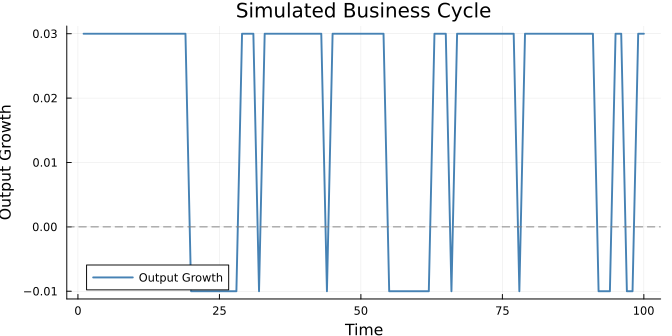

In [1]:
plot(g, linewidth=2, color=:steelblue, label="Output Growth",
     title="Simulated Business Cycle", size=(700, 350))
hline!([0.0], color=:gray, linestyle=:dash, label="")
xlabel!("Time")
ylabel!("Output Growth")

### Animating the Markov Chain


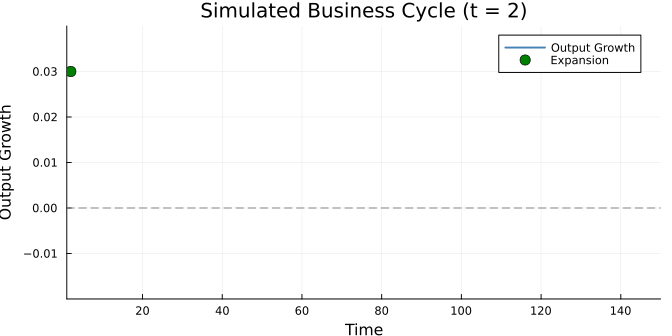

# Expectations

## Expected Values

### Expected Value of a Discrete Random Variable

-   The expected value is the probability-weighted average of all
    possible values:

$$
\mathbb{E}[X] = p_1 \bar X_1 + p_2 \bar X_2 + \ldots + p_n \bar X_n = \sum_{j=1}^n p_j \bar X_j
$$

. . .

-   In Julia, this is a **dot product**!

### Computing Expected Values

In [1]:
# Fair coin toss
p = [0.5, 0.5]
w̄ = [-1., 1.]
Ew = dot(p, w̄)   # expected winnings

0.0

In [1]:
# Loaded coin toss
p = [0.8, 0.2]
Ew = dot(p, w̄)   # expected winnings

-0.6000000000000001

. . .

-   This is the same as computing it manually:

In [1]:
p[1]*w̄[1] + p[2]*w̄[2]

-0.6000000000000001

### Monte Carlo Verification

-   We can verify using simulation (law of large numbers):

In [1]:
N = 100000                          # Number of draws
w_simulations = zeros(N)            # Pre-allocate results

for i in 1:N                        # Simulate N coin tosses
    s, w = drawDiscrete(p, w̄)      # Toss coin, get winnings
    w_simulations[i] = w            # Store the result
end
mean(w_simulations)                 # Sample average ≈ true expectation

-0.5963

. . .

> **Monte Carlo Method**
>
> As $N \to \infty$, the sample average converges to the true expected
> value.

## Conditional Expectations

### Conditional Expectations for Markov Chains

-   For a Markov chain we can compute **conditional expectations**:

$$
\mathbb{E}[X_{t+1} | X_t = \bar X_i]
$$

. . .

-   Since the conditional distribution is given by row $i$ of $P$:

$$
\mathbb{E}[X_{t+1} | X_t = \bar X_i] = \sum_j P_{i,j} \bar X_j
$$

### Conditional Expectations in Julia

In [1]:
# Expected growth rate conditional on boom
dot(P[1, :], ḡ)

0.026

In [1]:
# Expected growth rate conditional on recession
dot(P[2, :], ḡ)

0.0019999999999999996

### Conditional Expectations as Matrix Product

-   Each conditional expectation is a **dot product** of $\bar X$ with a
    row of $P$:

$$
\mathbb{E}[X_{t+1}|X_t = \bar X_i] = P_{i,\cdot} \cdot \bar X
$$

. . .

-   Stacking all rows together, this is just matrix multiplication:

$$
\left(\begin{matrix}\mathbb{E}[X_{t+1}|X_t = \bar X_1]\\\mathbb{E}[X_{t+1}|X_t = \bar X_2]\\\vdots\\\mathbb{E}[X_{t+1}|X_t = \bar X_n]\end{matrix}\right) = \left(\begin{matrix} P_{1,\cdot}\cdot \bar X \\ P_{2,\cdot}\cdot \bar X \\ \vdots \\ P_{n,\cdot}\cdot \bar X\end{matrix}\right) = P\bar X
$$

. . .

> **Key Result**
>
> Each row of $P$ dotted with $\bar X$ gives one conditional
> expectation. Stacking them all is just $P\bar X$!

## Verifying with Simulation

### Setting Up the Simulation

In [1]:
s, g = simulateMarkov(P, ḡ, 5000)   # 5000 periods for convergence
T = length(g)

5000

### Computing Empirical Conditional Expectations

-   Collect output growth values preceded by expansions vs. recessions:

In [1]:
gboom = []                         # Will hold growth after booms
grec = []                          # Will hold growth after recessions

for t in 1:T-1                    # Loop over all periods
    if s[t] == 1                   # Was period t a boom?
        push!(gboom, g[t+1])      #   → save next period's growth
    else                           # Was period t a recession?
        push!(grec, g[t+1])       #   → save next period's growth
    end
end

### Comparing Empirical to Theoretical

-   Empirical conditional expectations:

In [1]:
[mean(gboom), mean(grec)]

2-element Vector{Float64}:
 0.02632931305715801
 0.0018143459915611817

. . .

-   Theoretical values ($P\bar X$):

In [1]:
P * ḡ

2-element Vector{Float64}:
 0.026
 0.0019999999999999996

### List Comprehension Alternative

-   More concise way using **list comprehensions**:

In [1]:
gboom = [g[t+1] for t in 1:T-1 if s[t] == 1]
grec  = [g[t+1] for t in 1:T-1 if s[t] == 2]

[mean(gboom), mean(grec)]

2-element Vector{Float64}:
 0.0263293130571578
 0.001814345991561181

. . .

> **Julia Tip**
>
> List comprehensions with `if` conditions are a powerful and concise
> way to filter and collect values!

# Estimating the Transition Matrix

## Maximum Likelihood Estimation

### The Estimation Problem

-   So far we’ve **assumed** the transition matrix $P$ is known
-   In practice, we observe a sequence of states and want to
    **estimate** $P$

. . .

-   Suppose we observe a time series of states $s_1, s_2, \ldots, s_T$
-   **Question:** What transition matrix $P$ most likely generated this
    data?

. . .

> **Maximum Likelihood**
>
> Pick the parameters that make the observed data **most probable**.

### The Likelihood Function

-   The probability of observing the full sequence
    $s_1, s_2, \ldots, s_T$ is:

$$
L(P) = \prod_{t=2}^{T} P_{s_{t-1}, s_t}
$$

. . .

-   Taking logs (easier to work with):

$$
\log L(P) = \sum_{t=2}^{T} \log P_{s_{t-1}, s_t}
$$

### Counting Transitions

-   Define $n_{ij}$ = number of times we observe a transition from state
    $i$ to state $j$:

$$
n_{ij} = \sum_{t=2}^{T} \mathbf{1}(s_{t-1} = i,\; s_t = j)
$$

. . .

-   Then the log-likelihood simplifies to:

$$
\log L(P) = \sum_{i=1}^{n} \sum_{j=1}^{n} n_{ij} \log P_{ij}
$$

### The MLE Solution

-   Maximizing $\log L$ subject to $\sum_j P_{ij} = 1$ for each row $i$
    gives:

$$
\hat{P}_{ij} = \frac{n_{ij}}{\sum_{k=1}^{n} n_{ik}} = \frac{n_{ij}}{n_{i \cdot}}
$$

. . .

> **MLE of Transition Probabilities**
>
> The MLE estimate of $P_{ij}$ is simply the **fraction of transitions
> from state $i$ that go to state $j$**.

## Julia Implementation

### `countTransitions`: Pseudocode

-   First, let’s write a function to count transitions:

In [0]:
function countTransitions(s, n_states)
    # Initialize an n_states × n_states matrix of zeros
    # Loop through the sequence: for each consecutive pair (s[t-1], s[t])
    #   increment the count at position (i, j)
    # Return the count matrix
end

### `countTransitions`: Full Function

In [1]:
"""
    countTransitions(s, n_states)

Count transitions in state sequence `s` and return
an n_states × n_states matrix of counts.
"""
function countTransitions(s, n_states)
    N = zeros(Int, n_states, n_states)   # Initialize count matrix
    for t in 2:length(s)
        N[s[t-1], s[t]] += 1            # Increment the (i,j) count
    end
    return N
end

Main.Notebook.countTransitions

. . .

-   `N[i, j]` counts how many times the chain moved from state $i$ to
    state $j$
-   We start at $t = 2$ because each transition requires two consecutive
    observations

### `estimateTransitionMatrix`: Pseudocode

-   Normalize each row to get the MLE estimate:

In [0]:
function estimateTransitionMatrix(s, n_states)
    # Count transitions using countTransitions
    # Normalize: divide each row by its row sum
    # Return the estimated transition matrix
end

### `estimateTransitionMatrix`: Full Function

In [1]:
"""
    estimateTransitionMatrix(s, n_states)

Estimate the transition matrix from a state sequence
using maximum likelihood (row-normalized transition counts).
"""
function estimateTransitionMatrix(s, n_states)
    N = countTransitions(s, n_states)
    P̂ = N ./ sum(N, dims=2)              # Divide each row by its sum
    return P̂
end

Main.Notebook.estimateTransitionMatrix

### Testing on Our Simulated Data

-   Recall we simulated a Markov chain with:

In [1]:
P

2×2 Matrix{Float64}:
 0.9  0.1
 0.3  0.7

. . .

-   Let’s estimate from the simulated state sequence `s` ($T = 100$):

In [1]:
s = s[1:100]
P̂ = estimateTransitionMatrix(s, 2)

2×2 Matrix{Float64}:
 0.928571  0.0714286
 0.4       0.6

### How Close Are We?

-   Compare the true and estimated matrices:

In [1]:
println("True P: $(round.(P, digits=3))")
println("\nEstimated P̂: $(round.(P̂, digits=3))")
println("\nDifference (P̂ - P): $(round.(P̂ .- P, digits=3))")

True P: [0.9 0.1; 0.3 0.7]

Estimated P̂: [0.929 0.071; 0.4 0.6]

Difference (P̂ - P): [0.029 -0.029; 0.1 -0.1]

. . .

> **Consistency**
>
> As $T \to \infty$, the MLE $\hat{P}$ converges to the true $P$. With
> $T = 5{,}000$ we already get very close!

### How Sample Size Affects Accuracy

-   Let’s see how the estimate improves with more data:

In [1]:
sample_sizes = [50, 200, 1000, 5000, 20000]

errors = map(sample_sizes) do T_sim    #Fancy way to loop over sample sizes :)
    s_sim, _ = simulateMarkov(P, ḡ, T_sim)   # Simulate a Markov chain
    P̂_sim = estimateTransitionMatrix(s_sim, 2)
    return maximum(abs.(P̂_sim .- P))   # Max absolute error
end

hcat(sample_sizes, round.(errors, digits=4))

### How Sample Size Affects Accuracy

-   Let’s see how the estimate improves with more data:

In [1]:
sample_sizes = [50, 200, 1000, 5000, 20000]

errors = map(sample_sizes) do T_sim    #Fancy way to loop over sample sizes :)
    s_sim, _ = simulateMarkov(P, ḡ, T_sim)   # Simulate a Markov chain
    P̂_sim = estimateTransitionMatrix(s_sim, 2)
    return maximum(abs.(P̂_sim .- P))   # Max absolute error
end

hcat(sample_sizes, round.(errors, digits=4))

5×2 Matrix{Float64}:
    50.0  0.1235
   200.0  0.1412
  1000.0  0.0224
  5000.0  0.0093
 20000.0  0.0018

### Visualizing Convergence


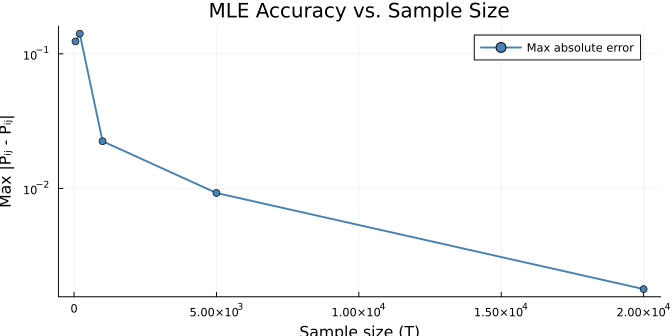

In [1]:
plot(sample_sizes, errors, marker=:circle, linewidth=2,
     color=:steelblue, label="Max absolute error", yscale=:log10,
     title="MLE Accuracy vs. Sample Size", size=(700, 350))
xlabel!("Sample size (T)")
ylabel!("Max |P̂ᵢⱼ - Pᵢⱼ|")

## Log-Likelihood and Numerical Optimization

### Computing the Log-Likelihood Directly

-   We can also compute the log-likelihood for any candidate $P$:

In [1]:
"""
    loglikelihood_mc(P, s)

Compute the log-likelihood of state sequence `s`
given transition matrix `P`.
"""
function loglikelihood_mc(P, s)
    ll = 0.0
    for t in 2:length(s)
        ll += log(P[s[t-1], s[t]])
    end
    return ll
end

Main.Notebook.loglikelihood_mc

### Comparing Log-Likelihoods

-   The MLE should have a **higher** log-likelihood than any other valid
    $P$:

In [1]:
P_wrong = [0.5 0.5;
           0.5 0.5]

println("Log-likelihood at P̂ (MLE):    ", round(loglikelihood_mc(P̂, s), digits=2))
println("Log-likelihood at true P:      ", round(loglikelihood_mc(P, s), digits=2))
println("Log-likelihood at P = 0.5 I:   ", round(loglikelihood_mc(P_wrong, s), digits=2))

Log-likelihood at P̂ (MLE):    -31.71
Log-likelihood at true P:      -32.47
Log-likelihood at P = 0.5 I:   -68.62

. . .

> **Key Insight**
>
> The MLE has the highest log-likelihood — it fits the observed data
> best. The true $P$ is close behind, while a naive equal-probability
> matrix does much worse.

### Visualizing the Likelihood Surface

-   With a $2 \times 2$ matrix, the free parameters are $P_{11}$ and
    $P_{22}$ (the persistence parameters)


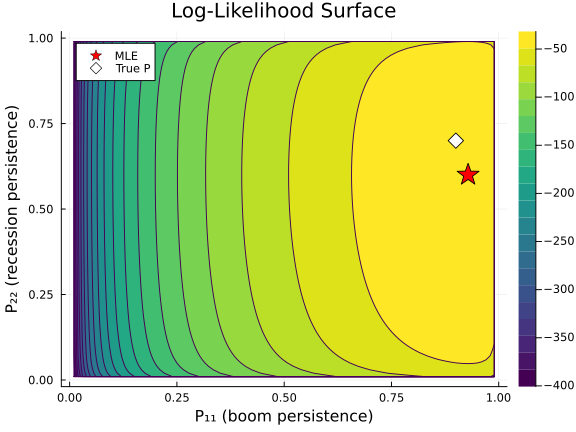

In [1]:
p11_grid = 0.01:0.01:0.99
p22_grid = 0.01:0.01:0.99

#Compute the log-likelihood for each combination of p11 and p22
ll_surface = [loglikelihood_mc([p11 1-p11; 1-p22 p22], s)
              for p11 in p11_grid, p22 in p22_grid]

#Plot the log-likelihood surface
contourf(p11_grid, p22_grid, ll_surface',
         xlabel="P₁₁ (boom persistence)",
         ylabel="P₂₂ (recession persistence)",
         title="Log-Likelihood Surface",
         color=:viridis, size=(600, 450), levels=20)
#Add the MLE and true P to the plot
scatter!([P̂[1,1]], [P̂[2,2]], marker=:star5, markersize=12,
         color=:red, label="MLE")
#Add the true P to the plot
scatter!([P[1,1]], [P[2,2]], marker=:diamond, markersize=8,
         color=:white, label="True P")

### Numerical MLE with `Optim.jl`

-   We can also let the computer **find** the peak of the likelihood
    surface
-   Use `Optim.jl` to minimize the **negative** log-likelihood

. . .

In [1]:
using Optim

### Setting Up the Optimization

-   Pack the free parameters into a vector $\theta = (P_{11}, P_{22})$
-   Reconstruct the full $2 \times 2$ matrix inside the objective:

In [1]:
function neg_loglik(θ, s)
    p11, p22 = θ                               # Unpack the parameters
    P_candidate = [p11 1-p11;                  # Construct the candidate matrix
                   1-p22  p22]
    return -loglikelihood_mc(P_candidate, s)   # negative log-likelihood to minimize
end

neg_loglik (generic function with 1 method)

### Running the Optimizer

-   Use box constraints to keep probabilities in $(0, 1)$:

In [1]:
θ₀ = [0.5, 0.5]                          # Initial guess (uniform)
result = optimize(θ -> neg_loglik(θ, s),  # Objective
                  [0.01, 0.01],           # Lower bounds
                  [0.99, 0.99],           # Upper bounds
                  θ₀,                     # Starting point
                  Fminbox(LBFGS()))        # Bounded L-BFGS algorithm

 * Status: success

 * Candidate solution
    Final objective value:     3.170994e+01

 * Found with
    Algorithm:     Fminbox with L-BFGS

 * Convergence measures
    |x - x'|               = 2.38e-10 ≰ 0.0e+00
    |x - x'|/|x'|          = 2.56e-10 ≰ 0.0e+00
    |f(x) - f(x')|         = 7.98e-11 ≰ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 2.52e-12 ≰ 0.0e+00
    |g(x)|                 = 8.80e-10 ≤ 1.0e-08

 * Work counters
    Seconds run:   0  (vs limit Inf)
    Iterations:    4
    f(x) calls:    36
    ∇f(x) calls:   36

### Extracting the Results

In [1]:
θ_mle = Optim.minimizer(result)
P̂_optim = [θ_mle[1] 1-θ_mle[1];
            1-θ_mle[2]  θ_mle[2]]

println("Optim MLE: $(round.(P̂_optim, digits=3))")
println("\nClosed-form MLE: $(round.(P̂, digits=3))")
println("\nTrue P: $(round.(P, digits=3))")

Optim MLE: [0.929 0.071; 0.4 0.6]

Closed-form MLE: [0.929 0.071; 0.4 0.6]

True P: [0.9 0.1; 0.3 0.7]

. . .

> **Verify**
>
> The numerical optimizer finds the same answer as our closed-form
> solution — a good sanity check! In more complex models where no closed
> form exists, `Optim.jl` is essential.

# Summary

### Key Takeaways

**Concepts**

-   Discrete random variables
-   Transition matrices
-   Markov chain simulation
-   Expected values as dot products
-   Conditional expectations as $P\bar X$
-   MLE: $\hat{P}_{ij} = n_{ij} / n_{i\cdot}$

**Julia Tools**

-   `Distributions`: `Categorical`, `rand`
-   `LinearAlgebra`: `dot`
-   `Optim`: numerical MLE
-   List comprehensions with filters
-   Transition counting & estimation

. . .

> **Remember**
>
> The transition matrix $P$ encodes everything about a Markov chain’s
> dynamics. Row $i$ gives the distribution of the next state given
> current state $i$. When $P$ is unknown, the MLE estimator — just
> counting and normalizing transitions — is simple, intuitive, and
> consistent.